# Disease Trend Analysis - EDA Notebook
### Internship Task: Gamage Recruiters (Pvt) Ltd
**Goal:** Analyze disease patterns and trends across patient demographics (age, gender, season, location).

**Dataset:** `Disease_Patient_Data.xlsx` (6000 patient records, 2024-2025)

---



In [1]:
# Import libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# make charts look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## Step 1: Load the Data
Load the patient dataset from Excel.




In [2]:
df = pd.read_excel("data/Disease_Patient_Data.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (6000, 6)


,Patient_ID,Date,Age,Gender,Location,Diagnosis
0,P00788,2024-01-01,43,Male,Batticaloa,Diarrheal Disease
1,P00685,2024-01-01,13,Male,Kurunegala,COVID-19
2,P03090,2024-01-01,37,Female,Kurunegala,Influenza
3,P01407,2024-01-01,9,Female,Ratnapura,Chickenpox
4,P02646,2024-01-01,20,Male,Ratnapura,Influenza


## Step 2: Process the Date Column
Convert the Date column from text to a real date type (datetime). This lets us extract month, year, and season easily.




In [3]:
# Convert Date column to proper datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check data type
print(df['Date'].dtype)
print("Earliest date:", df['Date'].min())
print("Latest date:", df['Date'].max())


datetime64[us]
Earliest date: 2024-01-01 00:00:00
Latest date: 2025-12-31 00:00:00


## Step 3: Extract Month / Season Information
We pull out the **Month**, **Month Name**, and **Season** from the Date column.

Sri Lanka has 4 seasons based on monsoon rains:
- **Northeast Monsoon**: Dec, Jan, Feb
- **First Inter-Monsoon**: Mar, Apr
- **Southwest Monsoon**: May, Jun, Jul, Aug, Sep
- **Second Inter-Monsoon**: Oct, Nov




In [4]:
# Extract month number and month name
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

# Function to map month -> Sri Lankan season
def get_season(month):
    if month in [12, 1, 2]:
        return "Northeast Monsoon"
    elif month in [3, 4]:
        return "First Inter-Monsoon"
    elif month in [5, 6, 7, 8, 9]:
        return "Southwest Monsoon"
    else:
        return "Second Inter-Monsoon"

df['Season'] = df['Month'].apply(get_season)

# Also make age groups (useful for demographic analysis)
def get_age_group(age):
    if age <= 12:
        return "Child (0-12)"
    elif age <= 19:
        return "Teen (13-19)"
    elif age <= 35:
        return "Young Adult (20-35)"
    elif age <= 55:
        return "Adult (36-55)"
    else:
        return "Senior (56+)"

df['Age_Group'] = df['Age'].apply(get_age_group)

df[['Date','Month','Month_Name','Season','Age','Age_Group']].head()


,Date,Month,Month_Name,Season,Age,Age_Group
0,2024-01-01,1,January,Northeast Monsoon,43,Adult (36-55)
1,2024-01-01,1,January,Northeast Monsoon,13,Teen (13-19)
2,2024-01-01,1,January,Northeast Monsoon,37,Adult (36-55)
3,2024-01-01,1,January,Northeast Monsoon,9,Child (0-12)
4,2024-01-01,1,January,Northeast Monsoon,20,Young Adult (20-35)


## Step 4: Analyze Disease Trends by Season
Count how many cases of each disease happen in each season.



In [5]:
# Count of each disease per season
season_disease = df.groupby(['Season', 'Diagnosis']).size().reset_index(name='Case_Count')
season_pivot = season_disease.pivot(index='Diagnosis', columns='Season', values='Case_Count').fillna(0)

# reorder seasons in a logical order (Sri Lanka calendar order)
season_order = ["Northeast Monsoon", "First Inter-Monsoon", "Southwest Monsoon", "Second Inter-Monsoon"]
season_pivot = season_pivot[season_order]
season_pivot


Season,Northeast Monsoon,First Inter-Monsoon,Southwest Monsoon,Second Inter-Monsoon
Diagnosis,,,,
COVID-19,151,92,252,85
Chickenpox,207,148,226,67
Dengue,96,178,519,286
Diarrheal Disease,162,197,290,82
Influenza,317,89,472,92
Malaria,137,67,187,179
Respiratory Infection,349,126,256,96
Typhoid,101,124,294,76


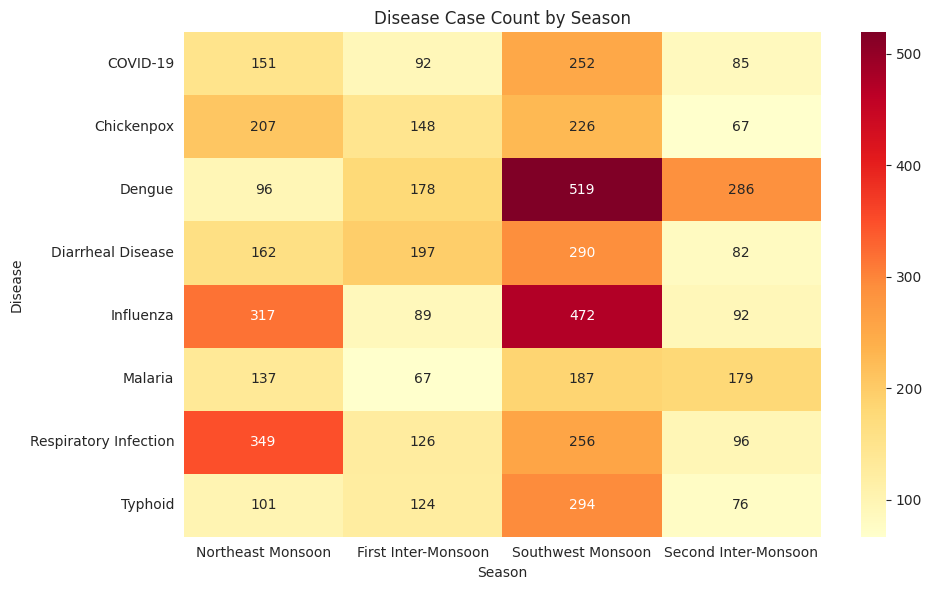

In [6]:
# Heatmap: Disease vs Season
plt.figure(figsize=(10,6))
sns.heatmap(season_pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title("Disease Case Count by Season")
plt.xlabel("Season")
plt.ylabel("Disease")
plt.tight_layout()
plt.savefig("charts/heatmap_disease_season.png", dpi=150)
plt.show()


## Step 5: Monthly Trend Line Charts
Line chart showing how each disease's case count changes month by month. This shows the seasonal pattern clearly over time.




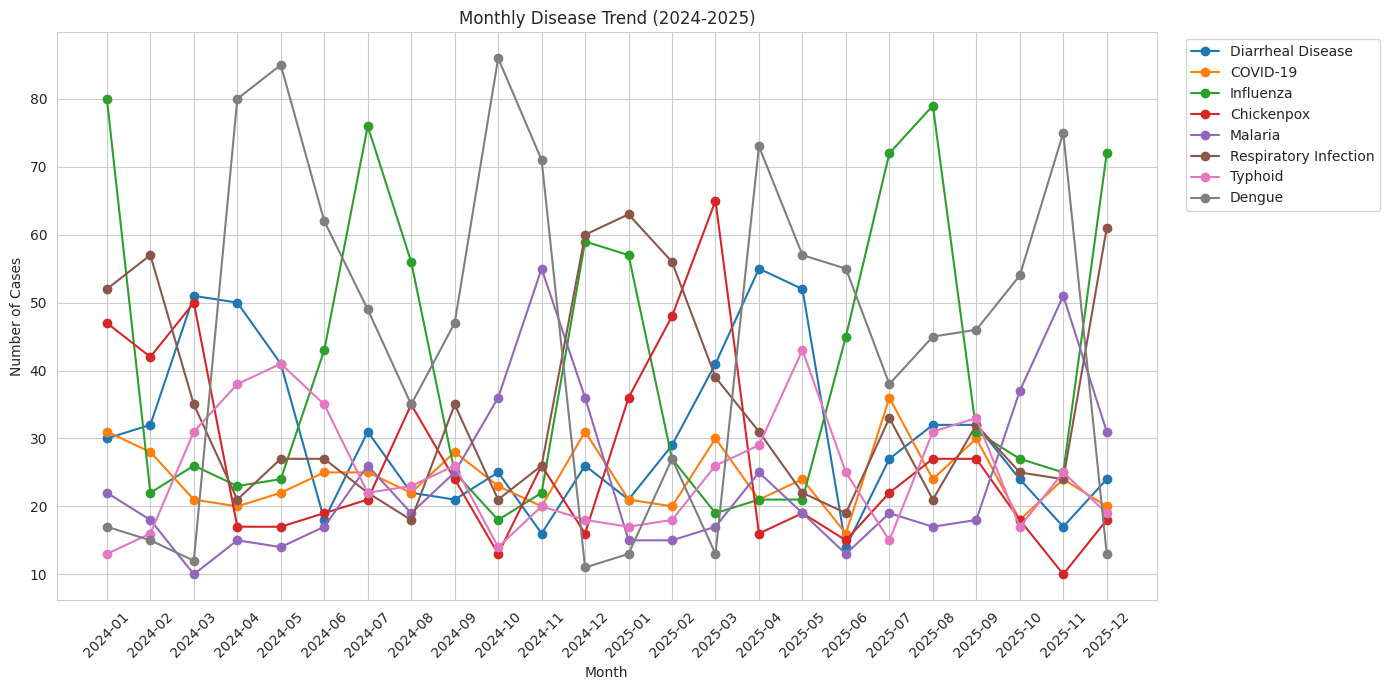

In [7]:
# Monthly case counts per disease (across full date range)
df['Year_Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby(['Year_Month', 'Diagnosis']).size().reset_index(name='Case_Count')

plt.figure(figsize=(14,7))
for disease in df['Diagnosis'].unique():
    subset = monthly_trend[monthly_trend['Diagnosis'] == disease]
    plt.plot(subset['Year_Month'], subset['Case_Count'], marker='o', label=disease)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.title("Monthly Disease Trend (2024-2025)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("charts/line_monthly_trend.png", dpi=150)
plt.show()


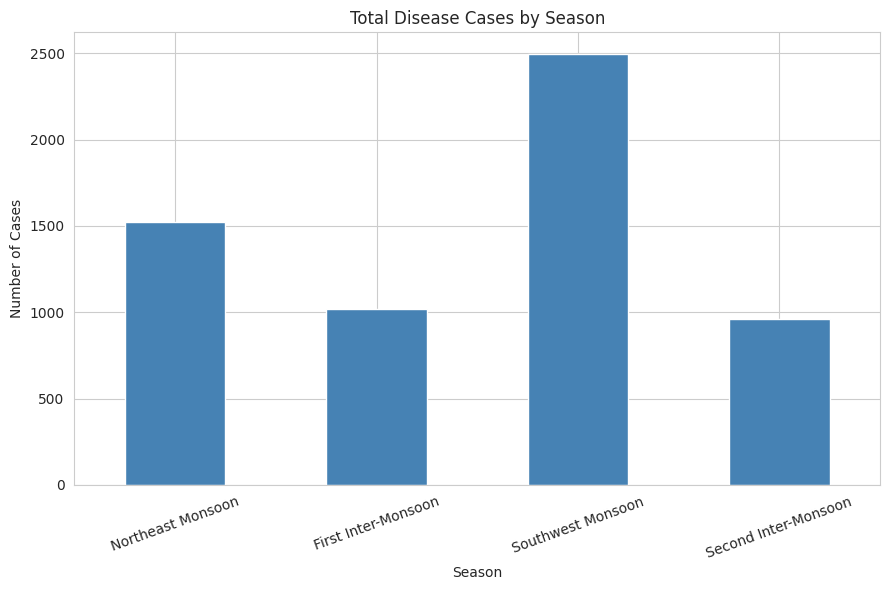

In [8]:
# Average cases by season overall (bar chart) - which season has most total illness
season_total = df.groupby('Season').size().reindex(season_order)

plt.figure(figsize=(9,6))
season_total.plot(kind='bar', color='steelblue')
plt.title("Total Disease Cases by Season")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("charts/bar_season_total.png", dpi=150)
plt.show()


## Step 6: Disease Distribution by Location
Which diseases are most common in which locations (districts/cities)?




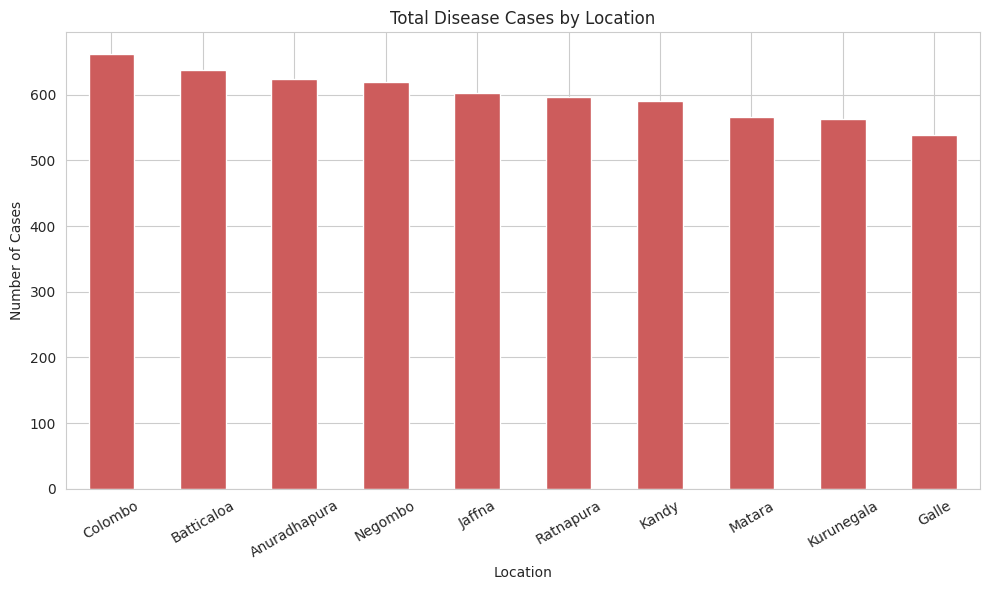

In [9]:
# Case counts by location
location_counts = df.groupby('Location').size().sort_values(ascending=False)

plt.figure(figsize=(10,6))
location_counts.plot(kind='bar', color='indianred')
plt.title("Total Disease Cases by Location")
plt.ylabel("Number of Cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/bar_location_total.png", dpi=150)
plt.show()


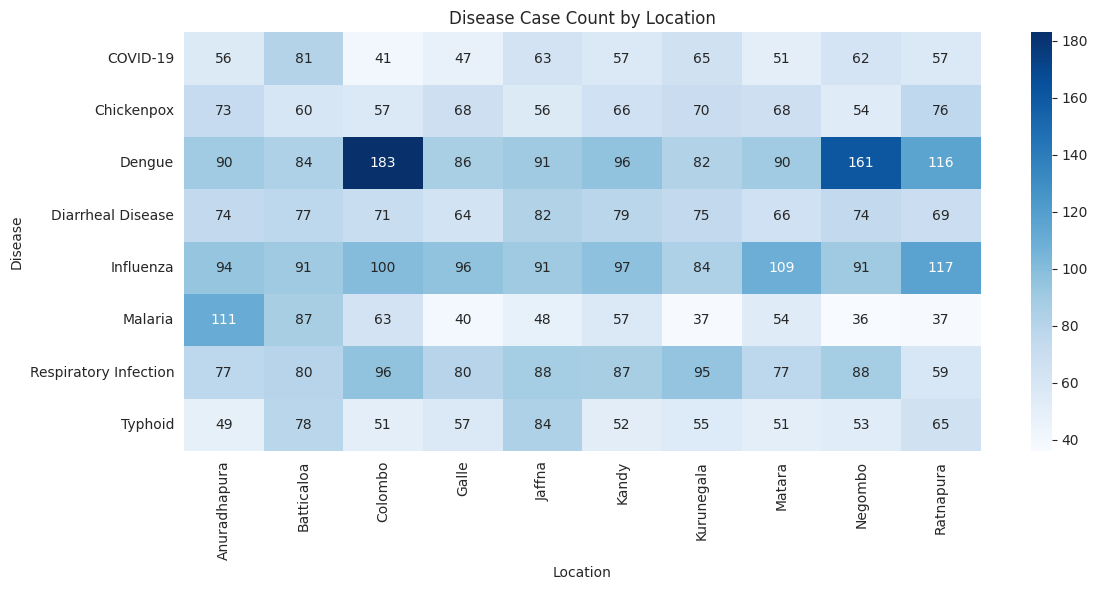

In [10]:
# Heatmap: Disease vs Location
location_disease = df.groupby(['Location', 'Diagnosis']).size().reset_index(name='Case_Count')
loc_pivot = location_disease.pivot(index='Diagnosis', columns='Location', values='Case_Count').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(loc_pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title("Disease Case Count by Location")
plt.xlabel("Location")
plt.ylabel("Disease")
plt.tight_layout()
plt.savefig("charts/heatmap_disease_location.png", dpi=150)
plt.show()


## Step 7: Demographic Breakdown (Age Group & Gender)
Extra useful analysis: which age groups and genders are most affected.

**Sinhala:** Kavuruda ekathara age group ekaka, gender ekaka wediya illness wenne kiyala balanawa.


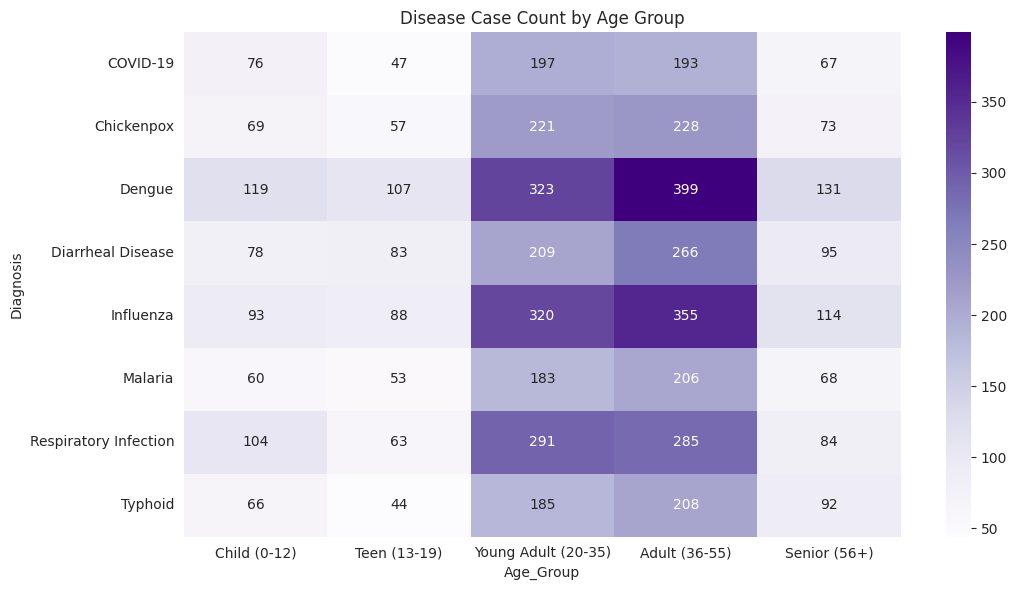

In [11]:
# Age group distribution across diseases
age_disease = df.groupby(['Age_Group', 'Diagnosis']).size().reset_index(name='Case_Count')
age_pivot = age_disease.pivot(index='Diagnosis', columns='Age_Group', values='Case_Count').fillna(0)

age_order = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-35)", "Adult (36-55)", "Senior (56+)"]
age_pivot = age_pivot[age_order]

plt.figure(figsize=(11,6))
sns.heatmap(age_pivot, annot=True, fmt='.0f', cmap='Purples')
plt.title("Disease Case Count by Age Group")
plt.tight_layout()
plt.savefig("charts/heatmap_disease_age.png", dpi=150)
plt.show()


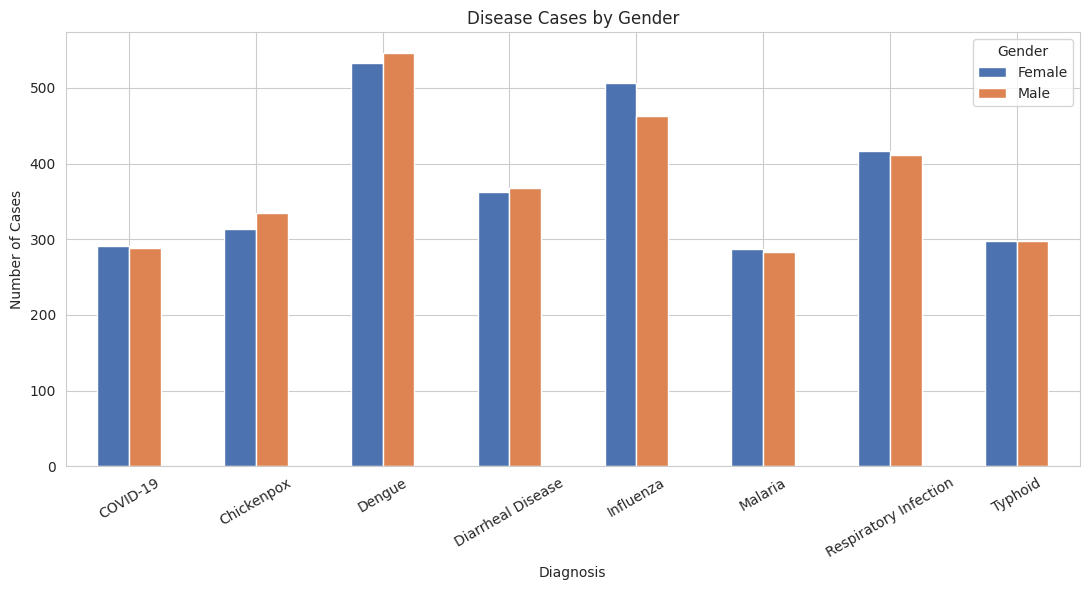

In [12]:
# Gender comparison
gender_disease = df.groupby(['Gender', 'Diagnosis']).size().unstack().T
gender_disease.plot(kind='bar', figsize=(11,6), color=['#4C72B0','#DD8452'])
plt.title("Disease Cases by Gender")
plt.ylabel("Number of Cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/bar_disease_gender.png", dpi=150)
plt.show()


## Step 8: Interactive Visualization (Plotly)
An interactive line chart — hover over points to see exact numbers. Useful for the dashboard.




In [13]:
fig = px.line(monthly_trend, x='Year_Month', y='Case_Count', color='Diagnosis',
              title='Interactive Monthly Disease Trend', markers=True)
fig.update_layout(xaxis_tickangle=-45, height=550)
fig.write_html("charts/interactive_monthly_trend.html")
fig.show()


In [14]:
# Interactive bar: cases by location, colored by disease
fig2 = px.bar(location_disease, x='Location', y='Case_Count', color='Diagnosis',
              title='Interactive: Disease Cases by Location', barmode='stack')
fig2.update_layout(height=550)
fig2.write_html("charts/interactive_location_disease.html")
fig2.show()


## Step 9: Key Insights Summary

**English:**
1. **Dengue peaks in Apr-Jun and Oct-Nov** (rainy inter-monsoon months) — matches expected mosquito breeding patterns.
2. **Respiratory Infections and Influenza rise in the Northeast Monsoon (Dec-Feb)** — cold, wet weather season.
3. **Diarrheal Disease increases in the First Inter-Monsoon (Mar-May)** — hot dry period before rains, often linked to water quality.
4. **Colombo and Negombo show the highest Dengue case counts** — dense urban areas.
5. **Anuradhapura and Batticaloa show higher Malaria counts** — consistent with historically malaria-prone dry zones.
6. **Children (0-12) show higher Chickenpox rates**; Adults (36-55) show more chronic/general illness spread across categories.
7. Case volume is fairly balanced between Male and Female patients overall, with small differences per disease.



---

